<img src="../images/bwHPC_Logo_cmyk.svg" width="200" /> <img src="../images/HochschuleEsslingen_Logo_RGB_DE.png" width="200" /> <img src="../images/Konstanz_Logo.svg" width="200" /> <img src="../images/KIT_Logo.png" width="200" />

# Regression with Neural Networks

In the previous notebook we let a neural network answer a *yes or no* question.
This time the answer is a **number**: given a residential district in California,
we want to predict **how expensive the houses there are**.

That makes this a **regression** problem — the target is a continuous numerical
value that can land anywhere on a scale, not one of a few fixed classes. The
network itself barely changes; what changes is the last layer, the loss function,
and the way we measure success.

---

## Contents

1. [What we want to predict](#task)
2. [The architecture](#network)
3. [The data](#data)
4. [Preparing the data](#prepare)
5. [Building the network](#build)
6. [Training the network](#train)
7. [Evaluation](#evaluation)

<a id="task"></a>
## 1. What we want to predict

The data comes from the 1990 California census. One row is **not** a single house
but a *district* — a small area of a few thousand people — described by eight
**features**:

| Feature | Meaning | Range |
|---|---|---|
| **longitude** | How far west the district lies | −124.35 – −114.31 |
| **latitude** | How far north the district lies | 32.54 – 41.95 |
| **housing_median_age** | Median age of the houses, in years | 1 – 52 |
| **total_rooms** | Total number of rooms in the district | 2 – 39,320 |
| **total_bedrooms** | Total number of bedrooms in the district | 1 – 6,445 |
| **population** | Number of people living in the district | 3 – 35,682 |
| **households** | Number of households in the district | 1 – 6,082 |
| **median_income** | Median household income, in tens of thousands of $ | 0.5 – 15.0 |

And one **target variable**:

| Target | Meaning | Range |
|---|---|---|
| **median_house_value_k** | Median house value in the district, in thousands of $ | 15.0 – 500.0 |

Eight numbers go in, one number comes out. Note the difference to the previous
notebook: there the output was `True` or `False`, and a prediction was either
right or wrong. Here the output is a value like `184.3`, and the question is no
longer *"is it correct?"* but *"how far off is it?"*.

<a id="network"></a>
## 2. The architecture

The structure is the same as before: an **input layer**, two **hidden layers**, and
an **output layer**, with every neuron connected to every neuron in the next layer.

On the left are the eight features of a district, on the right the single value we
want to predict.

![Neural network architecture](../images/nn_architecture_regression.svg)

The one visible difference to the classification network is the output: instead of
a probability between 0 and 1, that last neuron now has to produce a house value.
We will come back to what that means in [section 5](#build).

> If you want a detailed walk-through of what happens *inside* a single neuron —
> weights, bias, activation function — have a look at notebook
> `01_Classification_With_Neural_Networks.ipynb`. Here we take that as given.

<a id="data"></a>
## 3. The data

*Data source: [https://www.kaggle.com/datasets/camnugent/california-housing-prices](https://www.kaggle.com/datasets/camnugent/california-housing-prices)*

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("California_Housing_Prices.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value_k
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452.6
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358.5
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352.1
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341.3
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342.2


In [2]:
print("Rows:    ", len(df))
print("Columns: ", list(df.columns))
print("Missing: ", df.isna().sum().sum())

Rows:     20433
Columns:  ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value_k']
Missing:  0


### 3.1 A statistical summary

`describe()` is the quickest way to get a feel for the columns.

In [3]:
df.describe().round(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value_k
count,20433.00,20433.00,20433.00,20433.00,20433.00,20433.00,20433.00,20433.00,20433.00
mean,-119.57,35.63,28.63,2636.50,537.87,1424.95,499.43,3.87,206.86
std,2.00,2.14,12.59,2185.27,421.39,1133.21,382.30,1.90,115.44
min,-124.35,32.54,1.00,2.00,1.00,3.00,1.00,0.50,15.00
25%,-121.80,33.93,18.00,1450.00,296.00,787.00,280.00,2.56,119.50
50%,-118.49,34.26,29.00,2127.00,435.00,1166.00,409.00,3.54,179.70
75%,-118.01,37.72,37.00,3143.00,647.00,1722.00,604.00,4.74,264.70
max,-114.31,41.95,52.00,39320.00,6445.00,35682.00,6082.00,15.00,500.00


Two things are worth noticing:

- **The scales are wildly different.** `total_rooms` runs into the tens of
  thousands while `median_income` stays below 15 and `latitude` sits around 35.
  We will have to fix that in [section 4](#prepare).
- **The counting columns are extremely skewed.** For `total_rooms` the median is
  2,127 but the maximum is 39,320 — a handful of very large districts stretch the
  range far beyond where most of the data lives.

### 3.2 Where are the expensive districts?

Two of our features are pure geography — `longitude` and `latitude`. Plotting them
against each other draws a map of California, and colouring each point by its house
value shows immediately whether location matters.

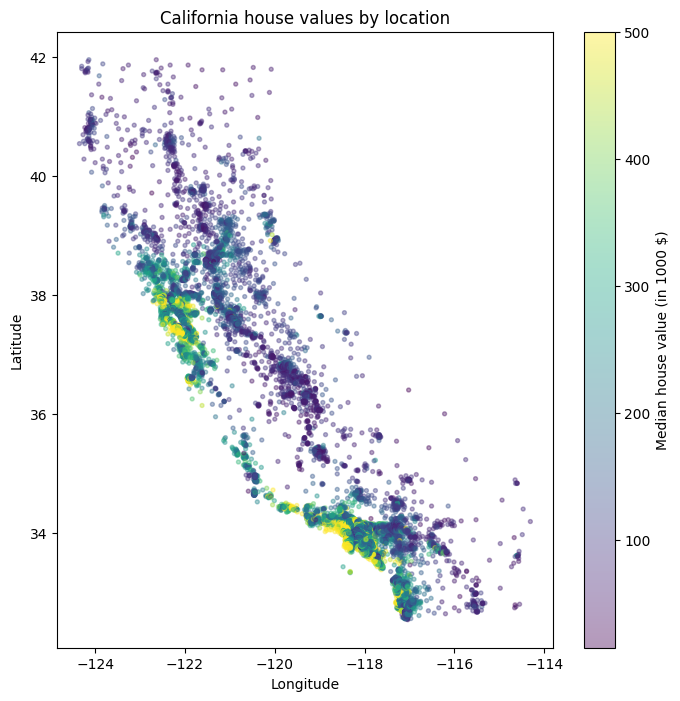

In [4]:
plt.figure(figsize=(8, 8))

plt.scatter(df["longitude"], df["latitude"],
            c=df["median_house_value_k"],
            cmap="viridis", s=8, alpha=0.4)

plt.colorbar(label="Median house value (in 1000 $)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("California house values by location")
plt.show()

The shape of California falls out of the data on its own — every point is a real
district, so the outline of the state and its coastline are simply where people
live.

The colours are the interesting part. The bright, expensive districts hug the
**coast**, and two clusters stand out in particular: the Bay Area around San
Francisco in the north, and the Los Angeles / San Diego strip in the south. Move
**inland**, into the Central Valley, and the map turns dark — the same house is
worth a fraction of what it would cost near the water.

This tells us something useful: `longitude` and `latitude` carry real information
about price, even though neither of them is a property of the house itself. It also
tells us the relationship is anything but a straight line — value does not rise
steadily as you travel west, it spikes around particular cities. That kind of
pattern is exactly what a neural network is good at picking up.

<a id="prepare"></a>
## 4. Preparing the data

### 4.1 Splitting into training and test data

As before, 20% of the districts are held back so we can measure performance on data
the network has never seen.

In [5]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="median_house_value_k")
y = df["median_house_value_k"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

print(f"Training rows: {len(X_train)}")
print(f"Test rows:     {len(X_test)}")

Training rows: 16346
Test rows:     4087


### 4.2 Scaling the features

The columns live on completely different scales, and the network would treat
`total_rooms` as far more important than `median_income` purely because its numbers
are bigger. **Standardisation** rescales every column to a mean of 0 and a standard
deviation of 1, which removes that distortion.

As always, the scaler is fitted on the **training data only**.

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = pd.DataFrame(scaler.transform(X_train),
                              columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test),
                             columns=X_test.columns, index=X_test.index)

X_train_scaled.describe().round(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
count,16346.00,16346.00,16346.00,16346.00,16346.00,16346.00,16346.00,16346.00
mean,0.00,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.39,-1.44,-2.20,-1.21,-1.28,-1.25,-1.30,-1.77
25%,-1.11,-0.79,-0.85,-0.54,-0.58,-0.56,-0.57,-0.69
50%,0.54,-0.64,0.03,-0.23,-0.24,-0.23,-0.23,-0.17
75%,0.78,0.98,0.66,0.23,0.26,0.26,0.28,0.46
max,2.62,2.96,1.85,16.82,14.05,30.06,14.60,5.86


Note that we scale the **features** only, not the target. Our house values are
already in thousands rather than in dollars, which keeps them in a comfortable
range for training — and it means every number the model reports later can be read
directly as "thousand dollars", without converting anything back.

<a id="build"></a>
## 5. Building the network

Eight inputs, two hidden layers, one output neuron.

The architecture figure in [section 2](#network) drew eight neurons per hidden
layer, simply because that made it readable. For the real model we use **64 neurons
per hidden layer**. The reason is the data: this dataset has 20,433 rows instead of
the 500 we had for the admissions example, with more varied and less linear
structure — that map in [section 3.2](#data) is not something eight neurons can
express. More neurons give the network more capacity to capture that complexity.

**No activation function on the output.** In the classification notebook the output
neuron used a sigmoid to squeeze the result into the range 0–1, because it had to
represent a probability. A house value has no such bounds — it can be 60, or 350,
or anything in between. So we leave the output neuron **linear**: whatever number
it computes is the prediction. Putting a sigmoid there would cap every prediction
at 1 and make the model useless.

**The loss function is the mean absolute error (MAE).** For each district it takes
the difference between the prediction and the true value, throws away the sign, and
averages over all districts:

> MAE = average of |prediction − actual|

Two things
make this a good choice here. It is measured in the **same unit as the target**, so
the number is directly interpretable — unlike a squared error, which would come out
in "thousand dollars squared".

We use MAE as both the loss (what training minimises) and the metric (what we
report), so the model is optimised for exactly the number we care about.

In [9]:
import tensorflow as tf
from tensorflow.keras import layers

model = tf.keras.Sequential([
    layers.Input(shape=[8]),                     # Input Layer  -- 8 features
    layers.Dense(units=64, activation="relu"),   # Hidden Layer 1
    layers.Dense(units=64, activation="relu"),   # Hidden Layer 2
    layers.Dense(units=1),                       # Output Layer -- no activation
])

model.compile(optimizer="adam",
              loss="mae",
              metrics=["mae"])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,801 (18.75 KB)

 Trainable params: 4,801 (18.75 KB)

 Non-trainable params: 0 (0.00 B)

<a id="train"></a>
## 6. Training the network

The training procedure is unchanged — the network works through the data in
**batches**, and one pass over the whole training set is one **epoch**. Only the
numbers are different, and both differences come from the size of the dataset:

- **`batch_size=256`** instead of 32. With over 16,000 training rows, a batch size
  of 32 would mean more than 500 weight updates per epoch, which is slow and
  needlessly noisy. Larger batches give smoother updates and run much faster.
  (Still a power of two, as is conventional.)
- **`epochs=500`** instead of 100. Regression on this data is a harder task than
  the admissions example, and the loss keeps improving well past 100 epochs.

Training will take a moment.

In [10]:
history = model.fit(X_train_scaled, y_train,
                    batch_size=256,
                    epochs=500,
                    verbose=1)      # verbose=1 prints a line per epoch

print("Training finished.")
print(f"Training MAE after 500 epochs: {history.history['mae'][-1]:.2f}")

Epoch 1/500
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 203.4756 - mae: 203.4756
Epoch 2/500
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 177.1868 - mae: 177.1868
Epoch 3/500
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 118.9800 - mae: 118.9800
Epoch 4/500
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 86.0095 - mae: 86.0095
Epoch 5/500
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 71.9359 - mae: 71.9359
Epoch 6/500
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 63.9470 - mae: 63.9470
Epoch 7/500
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 59.2663 - mae: 59.2663
Epoch 8/500
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 55.6428 - mae: 55.6428
Epoch 9/500
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 52.5624 - mae: 52.5624
Epoch 10/500
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 50.0559 - mae: 50.0559
Epoch 11/500
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 48.3440 - mae: 48.3440
Epoch 12/500
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 47.2426 - mae: 47.2426
Epoch 1

The loss curve shows whether training actually converged. A curve that has
flattened out means more epochs would not buy us much.

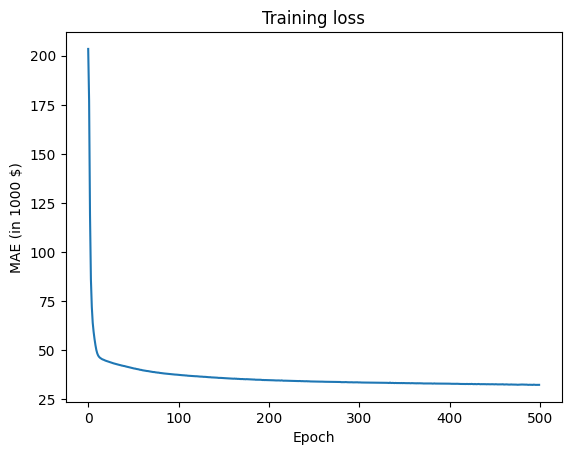

In [11]:
plt.plot(history.history["loss"])
plt.title("Training loss")
plt.xlabel("Epoch")
plt.ylabel("MAE (in 1000 $)")
plt.show()

<a id="evaluation"></a>
## 7. Evaluation

### 7.1 Three districts up close

Before looking at any summary number, let us simply take the first three districts
from the test set and compare what the network predicts against what they are
actually worth.

In [12]:
y_predict = model.predict(X_test_scaled, verbose=0).ravel()

comparison = pd.DataFrame({
    "predicted (1000 $)": y_predict[:3].round(1),
    "actual (1000 $)": y_test.to_numpy()[:3],
})
comparison["difference"] = (comparison["predicted (1000 $)"]
                            - comparison["actual (1000 $)"]).round(1)
comparison

,predicted (1000 $),actual (1000 $),difference
0,111.000000,98.9,12.1
1,157.600006,153.0,4.6
2,108.599998,91.3,17.3


The network does not hit the exact value for any of the three — and it never will. But the predictions are not wild guesses either; they land in the right
neighbourhood of the true value.

That is the whole character of a regression problem. There is no "correct" and
"incorrect" to count up, only distance. Which brings us to the question of how far
off the model is in general.

### 7.2 The mean absolute error over the whole test set

Three districts tell us nothing reliable. The MAE averages that same difference
over every district in the test set.

In [15]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_predict)

print(f"Test MAE: {mae:.2f}")

Test MAE: 33.55
